Class RandomWalk represents a grid of size $1\times N$. 

For each vertex $x$ of the grid we generate a uniform random variable on the interval $[0.1,0.9]$ -- $w[x]$. 

For each vertex we can pick two actions $a[x]\in \{0,1\}$. 

If action $a[x]=0$ is chosen then the random walk moves to the right with probability $\frac{w[x+1]}{w[x-1]+w[x+1]}$ and to the left with probability $\frac{w[x-1]}{w[x-1]+w[x+1]}$.

If action $a[x]=1$ is chosen then the random walk moves to the right with probability $\frac{w[x-1]}{w[x-1]+w[x+1]}$ and to the left with probability $\frac{w[x+1]}{w[x-1]+w[x+1]}$. 

$N$ -- size of grid 
$x$ -- initial position of the random walk. If not given then a random value on $[1,N-1]$ is assigned.

Here we consider policy evaluation for a fixed policy. 
We use Monte-Carlo and TD with fixed and varying alpha  for plocity evaluation

In [5]:
import numpy as np 
import matplotlib.pyplot as plt
import math 


class RandomWalk:

    def __init__(self, N): 
        self.N = N
        #self.w = np.random.uniform(low=0.1, high=0.9, size=N)
        self.w = np.ones(N)
        print(self.w)
        
        
    def is_state_terminal(self,x):
        return x == 0 or x == self.N-1 
    
    def random_start(self):
        return np.random.randint(0, self.N) 

    def next_step(self,  x, a):
        """
        If a=1 then it jumps to the right with probability w[x+1]/(w[x-1]+w[x+1]) and left otherwise. 
        If a=0 then it jumps to the right with probability w[x-1]/(w[x-1]+w[x+1]) and left otherwise. 

        :param a: action with possible values 0 or 1 

        return: state and reward 
        
        """
        if self.is_state_terminal(x):
            return (x,0) 
        total = self.w[x+1]+self.w[x-1]
        if a == 1:
            p = self.w[x+1]/total
        else:
            p = self.w[x-1]/total 
        
        if p>np.random.rand():
            x+=1
        else:
            x-=1    
       
        reward = 1 if x == self.N-1 else 0 
        return (x,reward) 
    


Class TD evaluates policy using TD control.
Here $alpha$ can be fixed or varying. 

In [6]:
class TD:
    
    def __init__(self, rw,alpha, M):

        self.rw = rw 
        self.alpha = alpha
        self.M = M
        self.V = np.zeros(rw.N)
        self.V_running = []
        for x in range(rw.N):
            self.V_running.append([])

    def alpha_t(self, x, fixed):
        
        return self.alpha  if fixed else self.alpha/math.pow(1+len(self.V_running[x]),0.9)
        

    def run(self,fixed):
        beta = 1
        for i in range(self.M): 
            x = self.rw.random_start()
            a = 1
            while not self.rw.is_state_terminal(x):
                (state,reward) = self.rw.next_step(x,a)
                self.V[x] += self.alpha_t(x,fixed)*(reward+beta*self.V[state]-self.V[x])
                self.V_running[x].append(self.V[x])
                x = state 
                a = 1 




Monte carlo with alpha

In [7]:
class MC_Alpha:
    
    def __init__(self, rw,alpha, M):

        self.rw = rw 
        self.alpha = alpha
        self.M = M
        self.V = np.zeros(rw.N)
        self.V_running = []
        for x in range(rw.N):
            self.V_running.append([])

    def pi(self,x):  # Fixed policy
        return 1
    
    def generate_episode(self, x):

        s = [x]
        a = self.pi(x)
        while not self.rw.is_state_terminal(x):
            (x,reward) = self.rw.next_step(x,a)
            s.append(x) 
            a = self.pi(x)
        
        return s

    def alpha_t(self, x, fixed):
        
        return self.alpha  if fixed else self.alpha/math.pow(1+len(self.V_running[x]),0.9)
        

    def run(self,fixed):
        beta = 1
        for i in range(self.M): 
            x = self.rw.random_start()
            a = 1
            episode = self.generate_episode(x)
            T = len(episode) 
            if episode[T-1] == self.rw.N-1:
                g = 1
            else:
                g = 0     
            for j in range(T-1, -1, -1):
                x = episode[j]
                self.V[x]+= self.alpha_t(x,fixed)*(g-self.V[x])
                self.V_running[x].append(self.V[x])
                


[1. 1. 1. 1. 1. 1.]


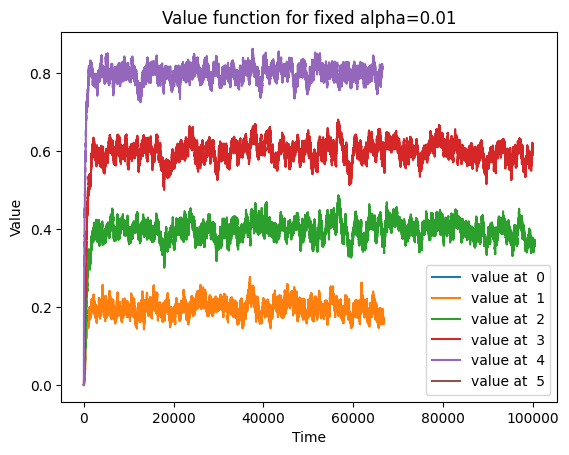

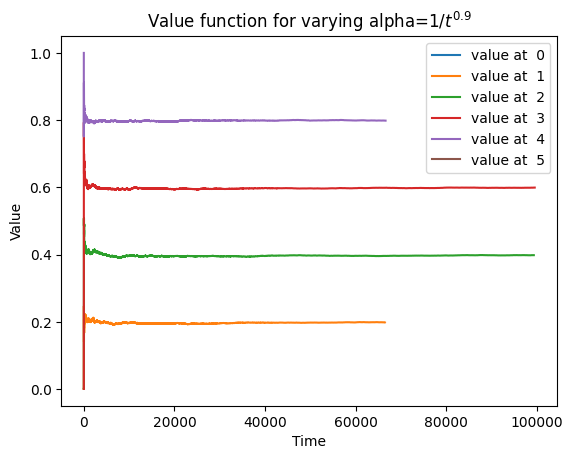

Varying alpha
[0.         0.19818495 0.39806474 0.59921838 0.79843342 0.        ]


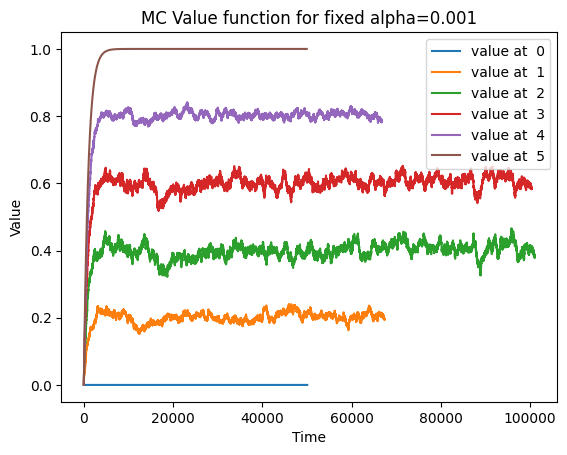

MC fixed alpha
[0.         0.19600678 0.3791191  0.5831751  0.78866938 1.        ]


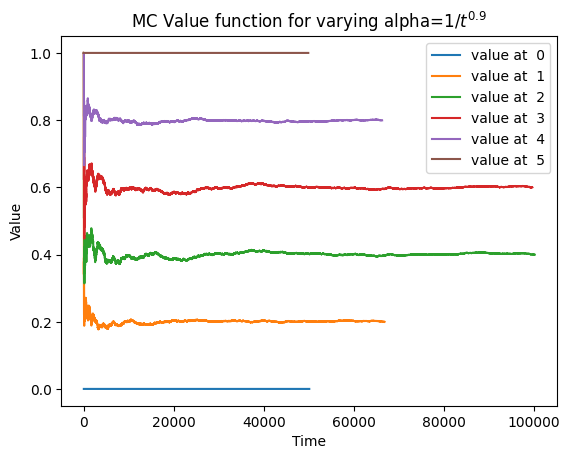

MC varying alpha
[0.         0.19992672 0.39965676 0.59973126 0.79930549 1.        ]


In [8]:
def main():

    #mc(6)
    M=100000
    N=6 


    #### TD with fixed alpha

    rw = RandomWalk(N)
    alpha = 0.01
    td = TD(rw,alpha,M)
    td.run(True)
    
    plt.figure(1)
    for x in range(N):
        plt.plot(td.V_running[x], label="value at  "+str(x))

    # Plot value functions in time 
    plt.xlabel('Time')
    plt.ylabel('Value')
    plt.title('Value function for fixed alpha='+str(alpha))
    plt.legend()

    #### TD with varying alpha

    alpha = 1
    td_varying = TD(rw,alpha,M)
    td_varying.run(False)
    
    plt.figure(2)
    
    for x in range(N):
        plt.plot(td_varying.V_running[x], label="value at  "+str(x))

    # Plot value functions in time 
    plt.xlabel('Time')
    plt.ylabel('Value')
    plt.title('Value function for varying alpha='+str(alpha)+'/$t^{0.9}$')
    plt.legend()

    plt.show()

    print("Varying alpha")
    print(td_varying.V)

    #### Monte-Carlo with fixed alpha

    alpha = 0.001
    mc = MC_Alpha(rw,alpha,M)
    mc.run(True)
    
    plt.figure(3)
    
    for x in range(N):
        plt.plot(mc.V_running[x], label="value at  "+str(x))

    # Plot value functions in time 
    plt.xlabel('Time')
    plt.ylabel('Value')
    plt.title('MC Value function for fixed alpha='+str(alpha))
    plt.legend()

    plt.show()

    print("MC fixed alpha")
    print(mc.V)

    #### Monte-Carlo with varying alpha

    alpha = 1
    mc_varying = MC_Alpha(rw,alpha,M)
    mc_varying.run(False)
    
    plt.figure(3)
    
    for x in range(N):
        plt.plot(mc_varying.V_running[x], label="value at  "+str(x))

    # Plot value functions in time 
    plt.xlabel('Time')
    plt.ylabel('Value')
    plt.title('MC Value function for varying alpha='+str(alpha)+'/$t^{0.9}$')
    plt.legend()

    plt.show()

    print("MC varying alpha")
    print(mc_varying.V)


if __name__ == "__main__":
    # Call the main function
    main()